### Author: Allan R. Jeeboo 
### Preferred Name: Vyncent S. A. van der Wolvenhuizen 
### Affiliation: Data Science Student at TripleTen 
### Email: vanderwolvenhuizen.vyncent@proton.me 
### Date started: 2025-04-05 
### Last updated: 2025-04-16 19:37

# 1.0 Introduction 
For this project, we'll be assuming the role of a data scientist at the OilyGiant mining company. Our task is to find the best place for a new well.

Steps to choose the location:

 1. Collect the oil well parameters in the selected region: oil quality and volume of reserves. 
 2. Build a model for predicting the volume of reserves in the new wells. 
 3. Pick the oil wells with the highest estimated values.
 4. Pick the region with the highest total profit for the selected oil wells. 
We have data on oil samples from three regions. Parameters of each oil well in the region are already known. We'll build a model that will help to pick the region with the highest profit margin, then analyze potential profit and risks using the Bootstrapping technique.

Workflow Path: 
 1. **Data Import and Overview**: We'll begin by loading the datasets for the three regions and perform an initial exploration. This includes examining the structure, size, and basic statistics of the data to understand its composition and identify any immediate issues.

 2. **Data Cleaning and Preprocessing**: Next we'll clean the data by addressing missing values, duplicates, and inconsistencies. We'll also standardize column names and formats to ensure uniformity across datasets, preparing them for analysis.

 3. **Exploratory Data Analysis (EDA)**: This step involves analyzing the data to uncover patterns, trends, and relationships among features. We'll use visualizations and statistical summaries to gain insights into the factors influencing oil reserves.

 4. **Model Creation**: In this phase, we develop predictive models for each region using linear regression. These models estimate the volume of reserves in new wells based on the features provided in the datasets.

 5. **Profit Calculation**: In this step, we calculate the potential profit for each region based on the predicted reserves and the cost of developing the wells. This involves identifying the top-performing wells and determining the revenue generated from their reserves.

 6. **Profit and Risk**: Here, we evaluate the profitability and associated risks for each region using statistical techniques like bootstrapping. This helps us estimate confidence intervals for profit and assess the likelihood of losses, enabling data-driven decision-making.

All of the information used throughout Section 1 comes from TripleTen's Sprint 9 [project overview](https://tripleten.com/trainer/data-scientist/lesson/676da3d0-d254-4f97-bec8-7178b52f9ff9/) page.

### 1.1 Data Import & Overview

In [86]:
import pandas as pd 
import math 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 
from sklearn.model_selection import train_test_split 

geo_0 = pd.read_csv('geo_data_0.csv') 
geo_1 = pd.read_csv('geo_data_1.csv') 
geo_2 = pd.read_csv('geo_data_2.csv') 

display('Geo 0:', geo_0.head(), f'rows, columns: {geo_0.shape}') 
display('Geo 1:', geo_1.head(), f'rows, columns: {geo_1.shape}') 
display('Geo 2:', geo_2.head(), f'rows, columns: {geo_2.shape}') 

'Geo 0:'

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


'rows, columns: (100000, 5)'

'Geo 1:'

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


'rows, columns: (100000, 5)'

'Geo 2:'

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


'rows, columns: (100000, 5)'

In [87]:
print(geo_0.info()) 
print() 
print(geo_1.info()) 
print() 
print(geo_2.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column

All three datasets share the same structure, with identical numbers of columns, rows, and data types. However, since they represent different regions, their values differ. It's important to note that this data is synthetic, meaning that contract details and well characteristics are not disclosed. 

### 1.2 Data Description

Column descriptions: 
- **id**: unique oil well identifier  

- **f0**, **f1**, **f2**: three features of points (their specific meaning is unimportant, but the features themselves are significant)  

- **product**: volume of reserves in the oil well (thousand barrels).  

Project conditions:

1. Only linear regression is suitable for model training (the rest are not sufficiently predictable).
2. When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
3. The budget for development of 200 oil wells is 100 USD million.
4. One barrel of raw materials brings $4.50 USD of revenue. The revenue from one unit of product is $4,500 USD (volume of reserves is in thousand barrels).
5. After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.
6. The data is synthetic: contract details and well characteristics are *not* disclosed. 

# 2.0 Data Preprocessing
Before proceeding to EDA, we need to ensure the data is clean and ready for analysis. The column formats are already consistent, so let's focus on identifying and addressing any missing values (NaNs) and duplicates. If issues are found, we'll resolve them; otherwise, we'll move forward to the exploratory data analysis phase.

### 2.1 NaNs

In [88]:
print(f'geo_0 nans:\n{geo_0.isna().sum()}\n\n', 
      f'geo_1 nans:\n{geo_1.isna().sum()}\n\n', 
      f'geo_2 nans:\n{geo_2.isna().sum()}') 

geo_0 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_1 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_2 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


No nans. Nice.

### 2.2 Duplicates

In [130]:
print(f'geo_0 duplicates:{geo_0.duplicated().sum()}\ngeo_1 duplicates:{geo_1.duplicated().sum()}\ngeo_2 duplicates:{geo_2.duplicated().sum()}') 

geo_0 duplicates:0
geo_1 duplicates:0
geo_2 duplicates:0


In [131]:
print(f'geo 0 duplicate ids:\n{geo_0['id'].duplicated().sum()}\ngeo 1 duplicate ids:\n{geo_1['id'].duplicated().sum()}\ngeo 2 duplicate ids:\n{geo_2['id'].duplicated().sum()}') 

geo 0 duplicate ids:
10
geo 1 duplicate ids:
4
geo 2 duplicate ids:
4


In [91]:
region_0, region_1, region_2 = geo_0.drop_duplicates(subset='id'), geo_1.drop_duplicates(subset='id'), geo_2.drop_duplicates(subset='id')

print(region_0.shape, 
      region_1.shape, 
      region_2.shape) 

(99990, 5) (99996, 5) (99996, 5)


There aren't any duplicate rows in the datasets; however, in the `id` column of all three datasets, there are duplicate values: ten in `geo_0`, four in `geo_1`, and four in `geo_2`. 

# 3.0 EDA 
In this section we'll explore the data and create visuals to see what information we can gather. Remember our target is the `product` column. Because the `id` column will interfere with our analysis due to being unique string values, we'll drop the aforementioned column in each section. 

Before we begin, let's call on the `.describe()` method to calculate and display descriptive statistics for all of the regions. This will provide insights into the distribution of numerical features, including measures like mean, standard deviation, minimum, maximum, and quartiles for each column in the dataset. 

In [92]:
print(f'Geo 0 description:\n{region_0.describe()}\n\n', 
      f'Geo 1 description:\n{region_1.describe()}\n\n', 
      f'Geo 2 description:\n{region_2.describe()}\n\n') 

Geo 0 description:
                 f0            f1            f2       product
count  99990.000000  99990.000000  99990.000000  99990.000000
mean       0.500454      0.250141      2.502629     92.499684
std        0.871844      0.504430      3.248149     44.288304
min       -1.408605     -0.848218    -12.088328      0.000000
25%       -0.072572     -0.200877      0.287784     56.497069
50%        0.502405      0.250252      2.515969     91.847928
75%        1.073626      0.700640      4.715035    128.563699
max        2.362331      1.343769     16.003790    185.364347

 Geo 1 description:
                 f0            f1            f2       product
count  99996.000000  99996.000000  99996.000000  99996.000000
mean       1.141209     -4.796608      2.494501     68.823916
std        8.965815      5.119906      1.703579     45.944663
min      -31.609576    -26.358598     -0.018144      0.000000
25%       -6.298551     -8.267985      1.000021     26.953261
50%        1.153055     -4.813

All regions exhibit similar standard deviations. However, the mean and quartiles for `geo_1` are noticeably lower compared to the other two regions. Additionally, there is a notable similarity in the `f2` feature between `geo_0` and `geo_2`. 

### 3.1 Geo 0
In this subsection, we'll analyze the data for `geo_0`. This involves examining the correlation between features and the target variable (`product`), visualizing the distribution of the target variable, and identifying any patterns or trends that may influence the predictive modeling process. By understanding the relationships and distribution of the data, we can gain insights that will guide the development of our predictive model. 

In [93]:
display(geo_0.head())
print(f'Rows, columns:\n{geo_0.shape}') 

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Rows, columns:
(100000, 5)


In [94]:
geo_0_corr = geo_0.drop(columns= 'id').corr()
print(geo_0_corr)

               f0        f1        f2   product
f0       1.000000 -0.440723 -0.003153  0.143536
f1      -0.440723  1.000000  0.001724 -0.192356
f2      -0.003153  0.001724  1.000000  0.483663
product  0.143536 -0.192356  0.483663  1.000000


Text(0, 0.5, 'Frequency')

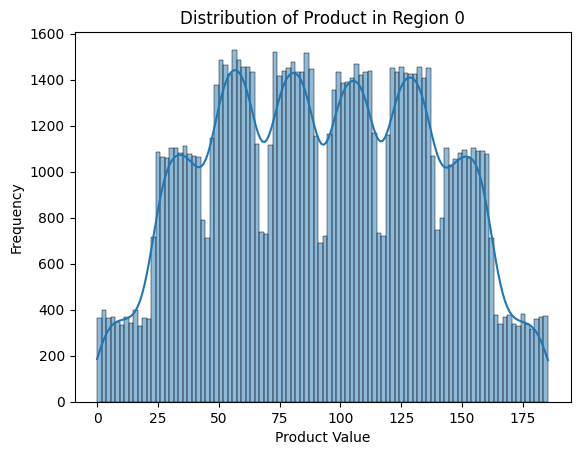

In [95]:
sns.histplot(data= geo_0, 
             bins= 100, 
             x= 'product', 
             kde= True) 

plt.title('Distribution of Product in Region 0') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency')

#### **Geo 0 Summary**
In this subsection, we analyzed the data for `geo_0`, focusing on the correlation between features and the target variable (`product`), as well as the distribution of the target variable. Here's a summary of our findings:
1. **Correlation Analysis**:
    - The correlation matrix revealed that the feature `f2` has the strongest positive correlation with the target variable (`product`) at **0.483**.
    - The features `f0` and `f1` have weaker correlations with the target variable, at **0.144** and **-0.192**, respectively.
    - This suggests that `f2` is the most significant predictor of `product` among the features.

2. **Distribution of `product`**:
    - The histogram of `product` values exhibits a multimodal distribution. Given that the data is synthetic and designed to simulate a real-world scenario, this pattern might result from the data generation process. 

### 3.2 Geo 1 
Let's repeat the steps performed in the previous section.

In [96]:
display(geo_1.head())
print(f'Rows, columns:\n{geo_1.shape}') 

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


Rows, columns:
(100000, 5)


In [97]:
region_1_corr = geo_1.drop(columns='id').corr()
print(region_1_corr)

               f0        f1        f2   product
f0       1.000000  0.182287 -0.001777 -0.030491
f1       0.182287  1.000000 -0.002595 -0.010155
f2      -0.001777 -0.002595  1.000000  0.999397
product -0.030491 -0.010155  0.999397  1.000000


Text(0, 0.5, 'Frequency')

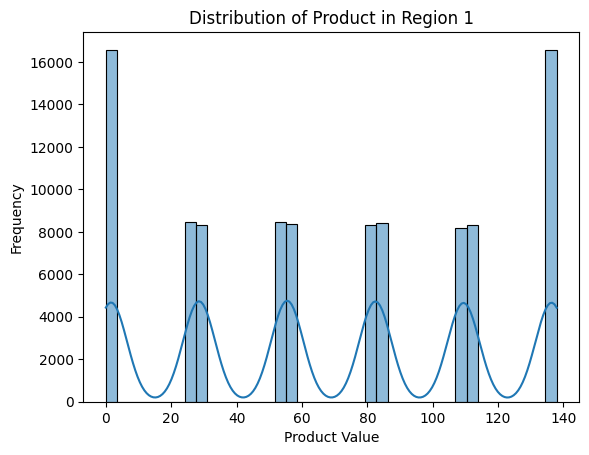

In [98]:
sns.histplot(data= geo_1, 
             x= 'product', 
             kde= True) 
plt.title('Distribution of Product in Region 1') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency') 

#### **Geo 1 Summary**
As with the previous subsection, we analyzed the data for `geo_1`, focusing on the correlation between features and the target variable (`product`), as well as the distribution of the target variable. Here's a summary of our findings:
1. **Correlation Analysis**:
    - Like `geo_1`, The correlation matrix revealed that the feature `f2` has the strongest positive correlation with the target variable (`product`) at **0.999**. This shows that there is an *extremely* strong correlation between `f2` and `product`. 
    - The features `f0` and `f1` have weaker correlations with the target variable, at **-0.030** and **-0.010**, respectively.
    - This suggests that `f2` is the most significant predictor of `product` among the features.

2. **Distribution of `product`**:
    - The histogram of `product` values shows a multimodal distribution similar to `geo_0`, though the patterns differ. As a reminder, since the data is synthetic and designed to mimic real-world scenarios, this distribution may result from the data generation process. 

### 3.3 Geo 2 
Once more! Let's replicate the steps from the previous sections. As a reminder, we'll be examining the correlation between features and the target variable (`product`), then visualize the distribution of the target variable using a histogram.

In [99]:
display(geo_2.head())
print(f'Rows, columns:\n{geo_2.shape}') 

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


Rows, columns:
(100000, 5)


In [100]:
region_2_corr = geo_2.drop(columns='id').corr()
print(region_2_corr)

               f0        f1        f2   product
f0       1.000000  0.000528 -0.000448 -0.001987
f1       0.000528  1.000000  0.000779 -0.001012
f2      -0.000448  0.000779  1.000000  0.445871
product -0.001987 -0.001012  0.445871  1.000000


Text(0, 0.5, 'Frequency')

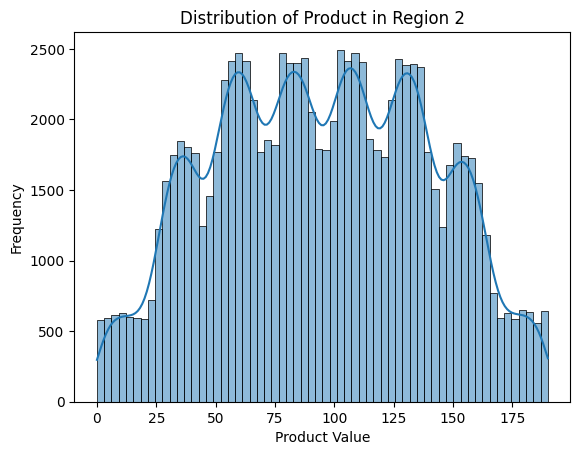

In [101]:
sns.histplot(data= geo_2, 
             x= 'product', 
             kde= True, ) 
plt.title('Distribution of Product in Region 2') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency') 

#### **Geo 2 Summary**
As with the previous two subsections, we analyzed the data for `geo_2`, focusing on the correlation between features and the target variable (`product`), as well as the distribution of the target variable. Here's a summary of our findings:
1. **Correlation Analysis**:
    - The correlation matrix revealed that the feature `f2` has the strongest positive correlation with the target variable (`product`) at **0.446**.
    - The features `f0` and `f1` have negligible correlations with the target variable, at **-0.002** and **-0.001**, respectively.
    - This suggests that `f2` is the most significant predictor of `product` among the features.

2. **Distribution of `product`**:
    - The histogram of `product` values exhibits a multimodal distribution. Similar to the other regions, this pattern might result from the synthetic nature of the data, which is designed to simulate real-world scenarios. 

### 3.4 EDA Summary

In this section, we examined the data for all three regions to uncover patterns, relationships, and distributions that would guide the predictive modeling process. Below is a summary of the findings:

**Geo 0**
1. **Correlation Analysis**:
    - Feature `f2` has the strongest positive correlation with the target variable (`product`) at **0.483**.
    - Features `f0` and `f1` have weaker correlations with `product`, at **0.144** and **-0.192**, respectively.

2. **Distribution of `product`**:
    - The histogram of `product` values exhibits a multimodal distribution, likely due to the synthetic nature of the data.

**Geo 1**
1. **Correlation Analysis**:
    - Feature `f2` has an extremely strong positive correlation with `product` at **0.999**, making it the most significant predictor.
    - Features `f0` and `f1` have negligible correlations with `product`, at **-0.030** and **-0.010**, respectively.

2. **Distribution of `product`**:
    - The histogram of `product` values shows a multimodal distribution, similar to `geo_0`.

**Geo 2**
1. **Correlation Analysis**:
    - Feature `f2` has the strongest positive correlation with `product` at **0.446**.
    - Features `f0` and `f1` have negligible correlations with `product`, at **-0.002** and **-0.001**, respectively.

2. **Distribution of `product`**:
    - The histogram of `product` values exhibits a multimodal distribution, consistent with the other regions.

#### EDA Key Observations
- Across all regions, feature `f2` consistently shows the strongest correlation with the target variable (`product`), making it the most significant predictor.
- The distributions of `product` values are multimodal in all regions, reflecting the synthetic nature of the data.
- While `geo_1` has the strongest correlation between `f2` and `product`, the other features (`f0` and `f1`) contribute minimally to the target variable in all regions. 

# 4.0 Model creation 
We'll now develop three **linear regression** models, one for each region, to predict the reserves per well. Additionally, we'll calculate the **RMSE** (Root Mean Squared Error) for each model. The RMSE is computed using the **mean_squared_error()** function from the **sklearn.metrics** library by passing the validation set targets and predictions, and then taking the square root of the result. For consistency, we'll set our **random state** to 12345. 

Note that calculating RMSE is important because it provides a measure of how well the model's predictions match the actual values. It quantifies the average magnitude of the prediction errors, with larger errors contributing more heavily due to the squaring operation. This helps us evaluate the model's accuracy and compare its performance across different regions. 

### 4.1 Geo 0 Model
Let's develop a linear regression model for `geo_0` to predict the volume of reserves (`product`) based on the features provided in the dataset. The process involves splitting the data into training and validation sets, training the model on the training set, and making predictions on the validation set. We'll then evaluate the model's performance by calculating the Root Mean Squared Error (RMSE) and analyzing the average predicted volume of reserves. This analysis will help us understand the model's accuracy and its ability to predict oil reserves in the region.

In [102]:
state = np.random.RandomState(12345)

features_0 = geo_0.drop(columns=['product', 
                                 'id'])
target_0 = geo_0['product']

features_0_train, features_0_valid, target_0_train, target_0_valid = train_test_split(features_0, 
                                                                                      target_0, 
                                                                                      test_size=0.25, 
                                                                                      random_state=state)

In [103]:
model_0 = LinearRegression()
model_0.fit(features_0_train, target_0_train) 
predictions_0 = model_0.predict(features_0_valid)

target_0_valid
predictions_0

predictions_0 = pd.DataFrame(predictions_0, 
                             columns= ['product']) 
predictions_0_mean = predictions_0.mean()

print(f'Predictions:\n{predictions_0},\n\n'f'Avg predicted volume:\n{predictions_0_mean}')

Predictions:
          product
0       95.894952
1       77.572583
2       77.892640
3       90.175134
4       70.510088
...           ...
24995  103.037104
24996   85.403255
24997   61.509833
24998  118.180397
24999  118.169392

[25000 rows x 1 columns],

Avg predicted volume:
product    92.592568
dtype: float64


In [104]:
rmse_0 = mean_squared_error(target_0_valid, predictions_0) ** 0.5 

print(f'RMSE for Geo 0: {rmse_0}')

RMSE for Geo 0: 37.5794217150813


#### Model 0 Summary
1. **Model Performance**:
    - The **Root Mean Squared Error (RMSE)** for the `geo_0` model (rounded to two decimal places) is **37.58**, indicating the average magnitude of prediction errors in thousands of barrels.

2. **Predicted Reserves**:
    - The **average predicted volume** of reserves is **92.59 thousand barrels**.

These results suggest that the model provides a reasonable estimate of reserves, though the RMSE indicates some variability in predictions. 

### 4.2 Geo 1 Model

In [105]:
features_1 = geo_1.drop(columns= ['product', 
                                  'id']) 
target_1 = geo_1['product'] 

features_1_train, features_1_valid, target_1_train, target_1_valid = train_test_split(features_1, 
                                                                                      target_1, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= state) 

model_1 = LinearRegression()
model_1.fit(features_1_train, target_1_train)

predictions_1 = model_1.predict(features_1_valid)
predictions_1 = pd.DataFrame(predictions_1, 
                             columns= ['product'])

predictions_1_mean = predictions_1.mean() 

print(f'Predictions:\n{predictions_1},\n\n'f'Avg predicted volume: {predictions_1_mean}') 

Predictions:
          product
0       54.238152
1       83.217878
2        2.971467
3       25.916480
4      111.341137
...           ...
24995   26.722422
24996   81.570895
24997   83.901769
24998   -1.259473
24999   26.169570

[25000 rows x 1 columns],

Avg predicted volume: product    68.769951
dtype: float64


In [106]:
values_1 = []
for i in range(1000):
    random_seed = state.randint(0, 10000)  # Generate a random seed for each iteration
    subsample_1 = geo_1.sample(frac=1, replace=True, random_state=random_seed)
    numeric_subsample_1 = subsample_1.select_dtypes(include=[np.number])  # Select only numeric columns
    values_1.append(numeric_subsample_1.quantile(q=0.99).values)  

values_1 = pd.DataFrame(values_1, columns=numeric_subsample_1.columns)  

values_1_upper = values_1.quantile(q=0.975) 
values_1_lower = values_1.quantile(q=0.025) 

In [107]:
print(f'Upper quantile:\n{values_1_upper}\n\n', 
      f'Lower quantile:\n{values_1_lower}\n\n')

print(f'rows, columns:\nfeatures_train:\n{features_1_train.shape}\n\n', 
      f'target_train:\n{target_1_train.shape}\n\n', 
      f'features_valid:\n{features_1_valid.shape}\n\n', 
      f'target_valid:\n{target_1_valid.shape}')

Upper quantile:
f0          18.982859
f1           7.243381
f2           5.007944
product    137.945408
Name: 0.975, dtype: float64

 Lower quantile:
f0          18.761459
f1           7.034852
f2           5.007641
product    137.945408
Name: 0.025, dtype: float64


rows, columns:
features_train:
(75000, 3)

 target_train:
(75000,)

 features_valid:
(25000, 3)

 target_valid:
(25000,)


In [108]:
rmse_1 = mean_squared_error(target_1_valid, predictions_1) ** 0.5 

print(f'RMSE for Geo 1: {rmse_1}')

RMSE for Geo 1: 0.889736773768065


#### Model 1 Summary
1. **Model Performance**:  
    - The **Root Mean Squared Error (RMSE)** for the `geo_1` model (rounded to two decimal places) is **0.89**, indicating a very low average magnitude of prediction errors in thousands of barrels.  

2. **Predicted Reserves**:  
    - The **average predicted volume** of reserves is **68.77 thousand barrels**.  

These results suggest that the model provides highly accurate estimates of reserves, with minimal variability in predictions.

### 4.3 Geo 2 Model

In [109]:
features_2 = geo_2.drop(columns= ['product', 'id']) 
target_2 = geo_2['product'] 

features_2_train, features_2_valid, target_2_train, target_2_valid = train_test_split(features_2, 
                                                                                      target_2, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= state) 

model_2 = LinearRegression() 
model_2.fit(features_2_train, target_2_train) 

predictions_2 = model_2.predict(features_2_valid)
predictions_2 = pd.DataFrame(predictions_2, 
                             columns= ['product'])
predictions_2_mean = model_2.predict(features_2_valid).mean() 

print(f'Predictions:\n{predictions_2},\n\n'f'Avg predicted volume: {predictions_2_mean}') 

Predictions:
          product
0      100.945722
1       80.901088
2       71.858166
3       92.553389
4       67.210195
...           ...
24995   80.520281
24996   93.548804
24997  111.863928
24998  126.041872
24999   57.360557

[25000 rows x 1 columns],

Avg predicted volume: 94.9342727967311


In [110]:
values_2 = []
for i in range(1000):
    subsample = geo_2.sample(frac=1, replace=True, random_state=state)
    numeric_subsample = subsample.select_dtypes(include=[np.number]) 
    values_2.append(numeric_subsample.quantile(q=0.99).values)  

values_2 = pd.DataFrame(values_2, columns=numeric_subsample.columns)  

values_2_upper = values_2.quantile(q=0.975) 
values_2_lower = values_2.quantile(q=0.025) 

In [111]:
print(f'Upper quantile:\n{values_2_upper}\n\n', 
      f'Lower quantile:\n{values_2_lower}\n\n')

print(f'rows, columns:\n{features_2_train}:\n{features_2_train.shape}\n\n', 
      f'target_train:\n{target_2_train.shape}\n\n', 
      f'features_valid:\n{features_2_valid.shape}\n\n', 
      f'target_valid:\n{target_2_valid.shape}')

Upper quantile:
f0           4.095642
f1           4.063393
f2          10.578295
product    185.328101
Name: 0.975, dtype: float64

 Lower quantile:
f0           4.018579
f1           3.985882
f2          10.433315
product    184.648544
Name: 0.025, dtype: float64


rows, columns:
             f0        f1        f2
71413 -0.269914  0.027845  0.561485
47542 -0.411747 -2.250441  4.124997
31452  1.571190 -1.978253  5.392108
50045  1.725798  3.515537  3.584006
6388  -1.754160 -1.529946  8.108507
...         ...       ...       ...
53708 -0.967308  2.637792  0.160747
53276  0.629148 -3.177217  5.029556
35022 -0.346958  1.763027  3.040367
33643 -0.747041 -0.235618 -1.480739
86813  0.328334 -1.951400  7.192655

[75000 rows x 3 columns]:
(75000, 3)

 target_train:
(75000,)

 features_valid:
(25000, 3)

 target_valid:
(25000,)


In [112]:
predictions_2_valid = model_2.predict(features_2_valid)
rmse_2 = mean_squared_error(target_2_valid, predictions_2_valid) ** 0.5 

print(f'RMSE for Geo 2: {rmse_2}')  

RMSE for Geo 2: 39.97347917648822


#### Model 2 Summary
1. **Model Performance**:  
    - The **Root Mean Squared Error (RMSE)** for the `geo_2` model (rounded to two decimal places) is **39.97**, reflecting the average magnitude of prediction errors in thousands of barrels.  

2. **Predicted Reserves**:  
    - The **average predicted volume** of reserves is **94.93 thousand barrels**.  

These results indicate that the model provides a reasonable estimate of reserves, though the RMSE suggests some variability in predictions.  

### 4.4 Summary of Models 
The Average predicted reserves (thousands of barrels, formatted to two decimal places) for each region are as follows: 
- **Geo 0**: 92.60 
- **Geo 1**: 68.77
- **Geo 2**: 94.93. 

The respective RMSEs for each region (also formatted to two decimal places) are as follows: 
- **Geo 0**: 37.58
- **Geo 1**: 0.89
- **Geo 2**: 39.97. 

These results indicate that **Geo 0** and **Geo 2** have higher predicted reserves but also exhibit higher prediction errors, suggesting variability in the model's accuracy. Conversely, **Geo 1** has lower predicted reserves but demonstrates significantly lower prediction error, indicating a more consistent and reliable model for this region. 

# 5.0 Profit Calculation 
Now it's time to find what our profits are. First let's define the budget, revenue per unit, the number of wells to be built, and the amount of money alotted to build a well.

In [113]:
budget = 10**8 
revenue_per_unit = 4500 
revenue_per_barrel = 4.5
num_of_wells = 200 
price_per_point = budget // num_of_wells
print(f'Price per point: ${price_per_point}')
risk_threshold = 0.025 

Price per point: $500000


Since the total budget is $100 million and we plan to construct 200 wells, each well is allocated $500,000. Let's see how many barrels (in thousands) are needed to break even on investment. 

In [114]:
break_even = price_per_point / revenue_per_unit

print(f'Volume of reserves in thousands of barrels needed to break even:\n{break_even}') 

Volume of reserves in thousands of barrels needed to break even:
111.11111111111111


To break even, we need slightly more than 111,000 barrels. With this threshold established, we'll now identify the top 200 wells predicted to yield the highest volumes and sort in desceding order. Afterward, we'll use the `describe()` method to analyze the statistical properties of these predictions. 

In [115]:
def top_predictions(predictions, 
                    n=200): 
    predictions_sorted = sorted(predictions, 
                                reverse=True) 
    best_predictions = predictions_sorted[:n]
    return best_predictions

n = 200
top_predictions_0 = top_predictions(predictions_0['product'], n)
top_predictions_1 = top_predictions(predictions_1['product'], n)
top_predictions_2 = top_predictions(predictions_2['product'], n)

In [116]:
print('Description for top 200 wells in each region:')
print(f'Geo 0:\n{pd.Series(top_predictions_0).describe()}\n\n', 
      f'Geo 1:\n{pd.Series(top_predictions_1).describe()}\n\n', 
      f'Geo_2:\n{pd.Series(top_predictions_2).describe()}') 

Description for top 200 wells in each region:
Geo 0:
count    200.000000
mean     155.511654
std        6.351371
min      148.365941
25%      150.739383
50%      153.783724
75%      158.576864
max      180.180713
dtype: float64

 Geo 1:
count    200.000000
mean     138.748768
std        0.283047
min      138.423680
25%      138.529010
50%      138.708956
75%      138.859059
max      139.984575
dtype: float64

 Geo_2:
count    200.000000
mean     148.464644
std        4.824836
min      142.763654
25%      144.854680
50%      147.022512
75%      151.678377
max      165.942904
dtype: float64


Text(0.5, 0, 'Product Amount')

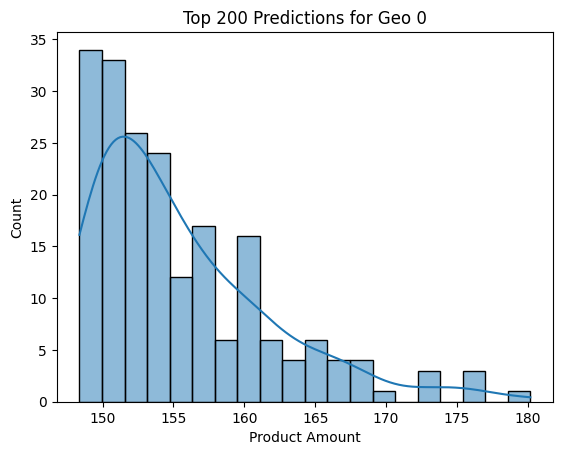

In [117]:
sns.histplot(data= top_predictions_0, 
             bins= 20, 
             kde= True) 

plt.title('Top 200 Predictions for Geo 0') 
plt.xlabel('Product Amount') 

Text(0.5, 0, 'Product Amount')

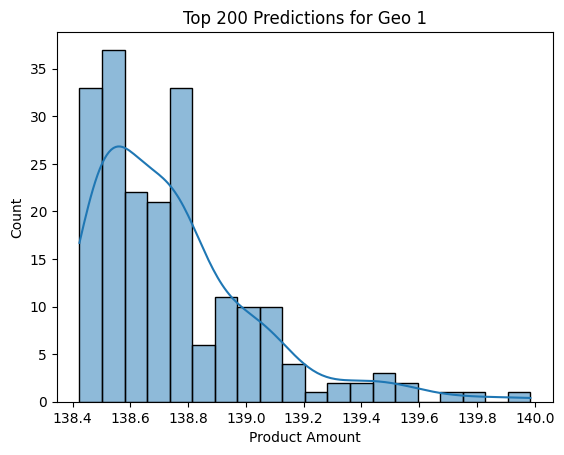

In [118]:
sns.histplot(data= top_predictions_1, 
             bins= 20, 
             kde= True) 

plt.title('Top 200 Predictions for Geo 1') 
plt.xlabel('Product Amount') 

Text(0.5, 0, 'Product Amount')

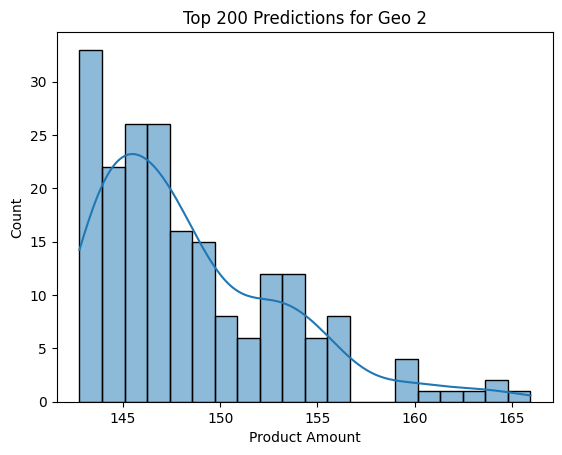

In [119]:
sns.histplot(data= top_predictions_2, 
             bins= 20, 
             kde= True) 

plt.title('Top 200 Predictions for Geo 2') 
plt.xlabel('Product Amount') 

**Geo 0 Top 200 Stats**  
**Geo 0 Top 200 Stats**  
- Highest mean, standard deviation, and quartile values among all regions.  
- Distribution is right-skewed.  

**Geo 1 Top 200 Stats**  
- Lowest mean, standard deviation (0.28), and quartile values.  
- Min and max values are tightly packed (138.42 to 139.98).  
- Distribution is right-skewed.  

**Geo 2 Top 200 Stats**  
- Intermediate values between Geo 0 and Geo 1.  
- Distribution is also right-skewed.  

**Note**  
`geo_1` is particularly noteworthy. Despite having the lowest stats of all three regions, its low standard deviation and tightly clustered data suggest more reliable and consistent results. 

To visualize the predicted volumes for the top 200 wells across all three regions, we'll use a scatterplot. The wells are sorted in descending order of predicted volume, meaning the wells with the highest predicted volumes will appear on the left side of the plot, while those with the lowest predicted volumes will appear on the right. This visualization will allow us to compare the distribution of predicted volumes across the regions effectively.

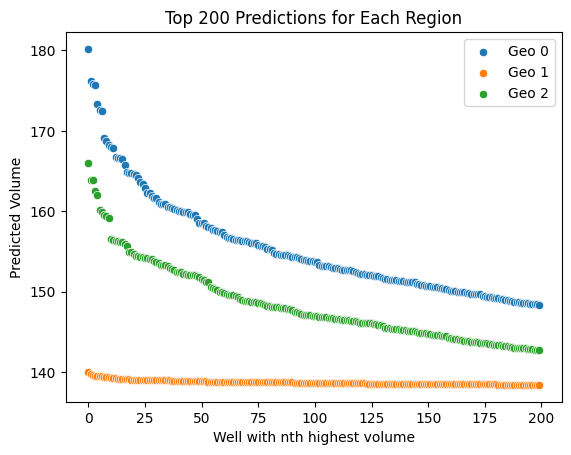

In [120]:
top_predictions_0_df = pd.DataFrame(top_predictions_0, 
                                    columns=['product'])
top_predictions_1_df = pd.DataFrame(top_predictions_1, 
                                    columns=['product'])
top_predictions_2_df = pd.DataFrame(top_predictions_2, 
                                    columns=['product'])

sns.scatterplot(data=top_predictions_0_df, 
                y='product', 
                x=top_predictions_0_df.index)
sns.scatterplot(data=top_predictions_1_df, 
                y='product', 
                x=top_predictions_1_df.index)
sns.scatterplot(data=top_predictions_2_df, 
                y='product', 
                x=top_predictions_2_df.index) 

plt.title('Top 200 Predictions for Each Region') 
plt.xlabel('Well with nth highest volume') 
plt.ylabel('Predicted Volume')
plt.legend(['Geo 0', 
            'Geo 1', 
            'Geo 2'])

The highest values for `geo_0` and `geo_2` appear to be outliers, while the rest of the data presents a steady distribution. As previously established, `geo_1` has tightly packed values, which is clearly reflected in this plot. 

Now that we've looked at that, let's move on to calculating profit. In the next cell, we'll define a function called `profit`. This function calculates the total profit for a given set of actual target values (`targets`) and predicted values (`predictions`). It selects the top wells with the highest predicted volumes, calculates the revenue from these wells, subtracts the total cost of developing the wells, and returns the resulting profit.

Here’s a breakdown of the parameters:
- `targets`: The actual values of the target variable (e.g., `product` column in the dataset).
- `predictions`: The predicted values from the model for the target variable.
- `wells_to_select`: The number of wells to select based on the highest predicted volumes (corresponds to `num_of_wells`).
- `revenue_per_unit`: The revenue generated per unit of product (corresponds to `revenue_per_unit`).
- `cost`: The cost of developing a single well (corresponds to `price_per_point`).

The function works as follows:
1. Converts `targets` and `predictions` to pandas Series and resets their indices for alignment.
2. Identifies the indices of the top 200 wells (`wells_to_select`) with the highest predicted volumes.
3. Extracts the actual volumes (`selected_volumes`) for these wells using the identified indices.
4. Calculates the total revenue as the sum of the selected volumes multiplied by `revenue_per_unit`.
5. Calculates the total cost as the number of selected wells multiplied by `cost`.
6. Computes the total profit by subtracting the total cost from the total revenue.
7. Returns the total profit. 

In [121]:
def profit(targets, 
           predictions, 
           wells_to_select= num_of_wells, 
           revenue_per_unit= revenue_per_unit, 
           cost= price_per_point):
    targets = pd.Series(targets).reset_index(drop= True)
    predictions = pd.Series(predictions).reset_index(drop= True)

    top_indices = predictions.sort_values(ascending= False).head(wells_to_select).index
    selected_volumes = targets.iloc[top_indices]

    total_revenue = selected_volumes.sum() * revenue_per_unit
    total_cost = wells_to_select * cost
    total_profit = total_revenue - total_cost

    return total_profit 

Now that we've defined our profit function, we'll create a variable called `regions`. The `regions` variable is a list containing the names of our three geographical regions. We'll create a for loop that will iterate over `regions`, valid targets from the validation set, and model predictions. Within the loop, we'll calculate the profit for each region using the `profit` function, passing the corresponding targets and predictions. This will allow us to determine the profit for each region efficiently. 

In [127]:
regions = ['geo_0', 'geo_1', 'geo_2']

print(f'For the 200 selected oil wells with the highest predicted volumes:\n')

for region, targets, predictions in zip(regions, 
                                        [target_0_valid, 
                                         target_1_valid, 
                                         target_2_valid], 
                                         [predictions_0['product'], 
                                          predictions_1['product'], 
                                          predictions_2['product']]):
    prof_region = profit(targets, predictions)
    print(f'The profit for {region}: ${prof_region:,.2f}\nPer well in {region}: ${prof_region/200:,.2f}\n') 

For the 200 selected oil wells with the highest predicted volumes:

The profit for geo_0: $33,208,260.43
Per well in geo_0: $166,041.30

The profit for geo_1: $24,150,866.97
Per well in geo_1: $120,754.33

The profit for geo_2: $24,424,206.01
Per well in geo_2: $122,121.03



### Summary of Profit Calculation

Our calculations suggest that `geo_0` will yield the highest profit among the three regions. However, this does not automatically confirm it as the best choice for investment. To make a data-driven decision, we need to evaluate the risks and uncertainties associated with each region. This involves sampling the data and calculating confidence intervals and risk metrics using statistical techniques like **bootstrapping** (A definition for this is provided below in the relevant section).

#### Profit Calculation Summary

In this section, we calculated the profit for each region based on the top 200 wells with the highest predicted volumes. The following steps were performed:

1. **Budget and Break-Even Analysis**:
    - The total budget was set to $100 million, with $500,000 allocated per well.
    - The break-even point was calculated as approximately 111,000 barrels.

2. **Top 200 Wells**:
    - The top 200 wells were selected for each region based on predicted volumes.
    - Statistical properties of these predictions were analyzed, including mean, standard deviation, and quartiles.

3. **Profit Calculation**:
    - A function was defined to calculate the total profit for the selected wells by subtracting the total cost from the revenue generated.
    - The profit for each region was computed:
      - **Geo 0**: $33,208,260.43
      - **Geo 1**: $24,150,866.97
      - **Geo 2**: $24,424,206.01

4. **Key Observations**:
    - Geo 0 and Geo 2 had higher predicted reserves but also exhibited higher variability in predictions.
    - Geo 1 had lower predicted reserves but demonstrated more consistent and reliable results.

This analysis provided a foundation for evaluating the profitability of each region, which was further refined in the subsequent risk analysis section. 

# 6.0 Profit and Risk 
Now this is where things get a little more complicated. Let's break down what we'll be doing. First, we're going to create a `bootstrap` function. Bootstrapping is a statistical method that involves repeatedly sampling data with replacement to estimate the variability of a dataset. By generating multiple resampled datasets, we can approximate the distribution of a statistic (e.g., mean, median, or profit) without relying on strict theoretical assumptions.

Our function will take the following five parameters: 
- targets: The actual values of the target variable (e.g., `product` column in the dataset).
- predictions: The predicted values from the model for the target variable.
- profit_fx: This parameter represents the `profit` function we defined in the previous section. It calculates the profit for a given set of targets and predictions.
- n: The number of times the bootstrap will be iterated. This determines how many resampled datasets will be created.
- sample_size: The size of each resampled dataset. This is the number of data points to include in each bootstrap sample.

The function works as follows:
1. It initializes an empty list called `profits` to store the profit values for each bootstrap iteration.
2. It resets the indices of the `targets` and `predictions` to ensure alignment during sampling.
3. For each iteration (up to `n`):
    - It randomly selects `sample_size` indices from the data with replacement.
    - It creates a resampled dataset using these indices for both `targets` and `predictions`.
    - It calculates the profit for the resampled dataset using the `profit` function (passed as an argument in place of the `profit_fx` parameter) and appends it to the `profits` list.
4. Finally, it returns the list of profits as a pandas Series.

This approach allows us to estimate the distribution of profits and calculate confidence intervals and risk metrics.

In the subsequent cells, we use this `bootstrap` function to simulate profits for each region (`geo_0`, `geo_1`, `geo_2`) based on the predictions and actual target values. We'll then calculate the **average profit**, **confidence intervals** (2.5th and 97.5th percentiles), and the **risk of loss** (percentage of bootstrap samples with negative profit) for each region. These results are stored in a dictionary and displayed as a DataFrame for easy comparison. 

A **confidence interval (CI)** is a range of values, derived from sample data, that is likely to contain the true value of an unknown population parameter. The confidence level (e.g., 95%) represents the proportion of times the interval would contain the true parameter if the experiment were repeated multiple times under the same conditions.

In our analysis, we chose a **95% confidence interval**, which means that we are 95% confident that the true average profit for each region lies within the calculated interval. The lower bound (2.5th percentile) and upper bound (97.5th percentile) of the interval are derived from the bootstrap simulation results. These bounds provide a measure of the variability in the profit estimates and help us assess the reliability of our predictions. 


In [123]:
def bootstrap(targets, 
              predictions, 
              profit_fx, 
              n= 1000, 
              sample_size= 500):
    profits = []
    targets = pd.Series(targets).reset_index(drop=True)
    predictions = pd.Series(predictions).reset_index(drop=True)
    
    for _ in range(n):
        sample = np.random.choice(len(targets), 
                                  size=sample_size, 
                                  replace=True)
        sampled_targets = targets.iloc[sample]
        sampled_predictions = predictions.iloc[sample]
        p = profit_fx(sampled_targets, 
                      sampled_predictions)
        profits.append(p)
    
    return pd.Series(profits)

In [ ]:
np.random.seed(12345)

target_map = {
    'geo_0': target_0_valid.reset_index(drop=True),
    'geo_1': target_1_valid.reset_index(drop=True),
    'geo_2': target_2_valid.reset_index(drop=True)
}

prediction_map = {
    'geo_0': predictions_0['product'].reset_index(drop=True),
    'geo_1': predictions_1['product'].reset_index(drop=True),
    'geo_2': predictions_2['product'].reset_index(drop=True)
}

In [ ]:
sample_results = {}
sample_profits = {}
sample_size = 500 

for region in regions:
    targets = target_map[region]
    predictions = prediction_map[region]

    region_profits = bootstrap(targets, 
                               predictions, 
                               profit_fx= profit, 
                               n= 1000, 
                               sample_size= sample_size)
    sample_profits[region] = region_profits

    sample_results[region] = {
        'avg_profit': region_profits.mean(),
        'ci_low': region_profits.quantile(0.025),
        'ci_high': region_profits.quantile(0.975),
        'risk_of_loss (%)': (region_profits < 0).mean() * 100
    }

# Final results DataFrame
boot_results = pd.DataFrame(sample_results).T
boot_results

,avg_profit,ci_low,ci_high,risk_of_loss (%)
geo_0,3.961650e+06,-1.112155e+06,9.097669e+06,6.9
geo_1,4.428504e+06,5.580193e+05,8.310233e+06,1.6
geo_2,3.560084e+06,-1.760179e+06,8.933159e+06,9.6


### Summary of Bootstrap Results

Our bootstrap analysis provides the following insights for each region:

1. **Geo 0**:
    - **Average Profit**: $3,961,649.85
    - **95% Confidence Interval**: [-$1,112,155.46, $9,097,669.42]
    - **Risk of Loss**: 6.9%

2. **Geo 1**:
    - **Average Profit**: $4,428,504.06
    - **95% Confidence Interval**: [$558,019.30, $8,310,233.31]
    - **Risk of Loss**: 1.6%

3. **Geo 2**:
    - **Average Profit**: $3,560,083.68
    - **95% Confidence Interval**: [-$1,760,179.02, $8,933,158.53]
    - **Risk of Loss**: 9.6%

### Key Observations:
- **Geo 1** has the highest average profit and the lowest risk of loss, making it the most favorable region for investment.
- **Geo 0** and **Geo 2** have higher risks of loss, with Geo 2 showing the highest risk at 9.6%.
- The confidence intervals for Geo 0 and Geo 2 include negative values, indicating potential losses in these regions. 

7.0 # Project Summary and Conclusion

## Objective
The goal of this project was to determine the most profitable region for developing new oil wells. This involved analyzing data from three regions (`geo_0`, `geo_1`, and `geo_2`), building predictive models to estimate oil reserves, and evaluating profitability and risks.

---

## Workflow Overview
1. **Data Import and Overview**:
    - Loaded datasets for the three regions.
    - Examined structure, size, and basic statistics of the data.

2. **Data Cleaning and Preprocessing**:
    - Checked for missing values and duplicates.
    - Addressed duplicate `id` values in all datasets.

3. **Exploratory Data Analysis (EDA)**:
    - Analyzed correlations between features and the target variable (`product`).
    - Visualized the distribution of `product` for each region.
    - Identified `f2` as the most significant predictor of `product`.

4. **Model Creation**:
    - Built linear regression models for each region to predict oil reserves.
    - Evaluated model performance using RMSE:
      - **Geo 0**: RMSE = 37.58
      - **Geo 1**: RMSE = 0.89
      - **Geo 2**: RMSE = 39.97

5. **Profit Calculation**:
    - Calculated the break-even point (111,000 barrels).
    - Selected the top 200 wells with the highest predicted reserves for each region.
    - Estimated profits:
      - **Geo 0**: $33,208,260.43
      - **Geo 1**: $24,150,866.97
      - **Geo 2**: $24,424,206.01

6. **Profit and Risk Analysis**:
    - Performed bootstrapping to simulate profits and calculate confidence intervals and risks.
    - Results:
      - **Geo 0**: Avg Profit = $3.96 million, Risk of Loss = 6.9%
      - **Geo 1**: Avg Profit = $4.43 million, Risk of Loss = 1.6%
      - **Geo 2**: Avg Profit = $3.56 million, Risk of Loss = 9.6%

---

## Key Findings
1. **Geo 1** is the most favorable region:
    - Highest average profit ($4.43 million).
    - Lowest risk of loss (1.6%).
    - Narrow confidence interval, indicating consistent results.

2. **Geo 0** and **Geo 2** have higher predicted reserves but also exhibit higher risks and variability in profits.

---

## Conclusion 
Initially I assumed that **Geo 0** would be the favored region due to it's high estimated profits and reserves; however,
based on our analysis, I would recommend **Geo 1** as the region for investment due to its high profitability and low risk. This decision is supported by the statistical analysis and predictive modeling we've performed. 